In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [2]:
np.random.seed(42)

In [5]:
# Use Day 4 data (new routine)
new_routine = np.random.normal(12000,1800,100)
print(f"sample mean = {new_routine.mean():.0f} steps")

sample mean = 12040 steps


In [7]:
# Step 2.1: 95% Confidence Interval
confidence = 0.95
n = len(new_routine)
mean = new_routine.mean()
std_err=stats.sem(new_routine) # std/sqrt(n)
t_critical = stats.t.ppf((1 + confidence) / 2. , n-1) # t-score
ci_lower = mean - t_critical * std_err
ci_upper = mean + t_critical * std_err
print(f"95% CI: [{ci_lower:.0f}, {ci_upper:.0f}] steps")
print(f"Business decision: '95% confident: {ci_lower:.0f}-{ci_upper:.0f} steps/day'")

95% CI: [11700, 12381] steps
Business decision: '95% confident: 11700-12381 steps/day'


Text(0.5, 1.0, 'Distribution + 95% CI')

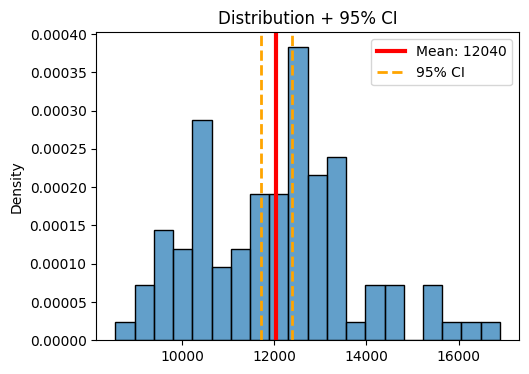

In [8]:
# Step 2.2: Visualize (CI = uncertainty "funnel")
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(new_routine, bins=20, stat='density', alpha=0.7)
plt.axvline(mean, color='red', lw=3, label=f'Mean: {mean:.0f}')
plt.axvline(ci_lower, color='orange', lw=2, ls='--', label='95% CI')
plt.axvline(ci_upper, color='orange', lw=2, ls='--')
plt.legend(); plt.title('Distribution + 95% CI')

In [11]:
# Step 2.3: Bootstrap CI (modern method - repeat Day 4 many times)
bootstrap_means = []
for _ in range(1000):
    sample = np.random.choice(new_routine, size=n, replace=True)
    bootstrap_means.append(sample.mean())

ci_boot_lower = np.percentile(bootstrap_means, 2.5)
ci_boot_upper = np.percentile(bootstrap_means, 97.5)

print(f"\nBootstrap 95% CI: [{ci_boot_lower:.0f}, {ci_boot_upper:.0f}]")


    


Bootstrap 95% CI: [11737, 12369]


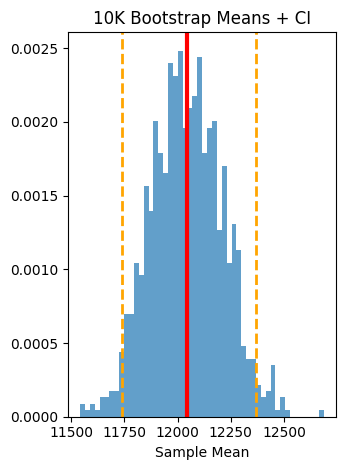

In [12]:
plt.subplot(1,2,2)
plt.hist(bootstrap_means, bins=50, alpha=0.7, density=True)
plt.axvline(np.mean(bootstrap_means), color='red', lw=3)
plt.axvline(ci_boot_lower, color='orange', lw=2, ls='--')
plt.axvline(ci_boot_upper, color='orange', lw=2, ls='--')
plt.title('10K Bootstrap Means + CI'); plt.xlabel('Sample Mean')
plt.tight_layout(); plt.show()